Step 1: Download the Data

In [12]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


Step 2: Explore the Data

First 5 rows:
        Place_ID X Date        Date Place_ID  target  target_min  target_max  \
0  010Q650 X 2020-01-02  2020-01-02  010Q650    38.0        23.0        53.0   
1  010Q650 X 2020-01-03  2020-01-03  010Q650    39.0        25.0        63.0   
2  010Q650 X 2020-01-04  2020-01-04  010Q650    24.0         8.0        56.0   
3  010Q650 X 2020-01-05  2020-01-05  010Q650    49.0        10.0        55.0   
4  010Q650 X 2020-01-06  2020-01-06  010Q650    21.0         9.0        52.0   

   target_variance  target_count  precipitable_water_entire_atmosphere  \
0           769.50            92                             11.000000   
1          1319.85            91                             14.600000   
2          1181.96            96                             16.400000   
3          1113.67            96                              6.911948   
4          1164.82            95                             13.900001   

   relative_humidity_2m_above_ground  ...  L3_SO2_sensor_zen

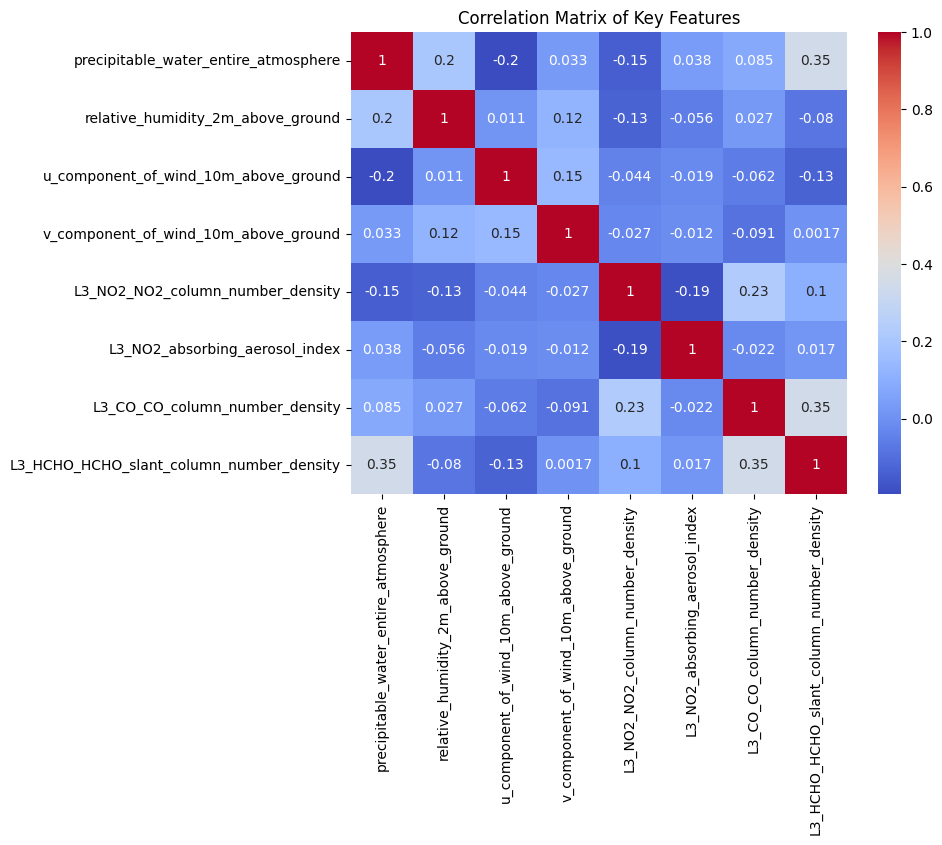

In [17]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Read the CSV into a DataFrame
df = pd.read_csv("Train.csv")

# Step 3: Basic overview of the dataset
print("First 5 rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

print("\nSummary statistics:")
print(df.describe())

# Step 4: Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


# Step 5: Select key features
# Based on df.head() and df.info(), identify actual column names
# 'wind_speed_10m_above_ground' was not found, instead using 'u_component_of_wind_10m_above_ground' and 'v_component_of_wind_10m_above_ground' if wind components are desired, or removing it if only direct speed was intended.
# For now, removing the problematic entry to proceed.
key_features = [
    'precipitable_water_entire_atmosphere',
    'relative_humidity_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground',
    'L3_NO2_NO2_column_number_density',
    'L3_NO2_absorbing_aerosol_index',
    'L3_CO_CO_column_number_density',
    'L3_HCHO_HCHO_slant_column_number_density'
]

# Create a new DataFrame with only the selected features
df_key = df[key_features]

print("\nSelected key features:")
print(df_key.head())

# Step 7: Check correlations
corr_matrix = df_key.corr()
print("\nCorrelation matrix:")
print(corr_matrix)

# Visualize correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Key Features")
plt.show()

Step 3: Apply Clustering (Unsupervised Task)

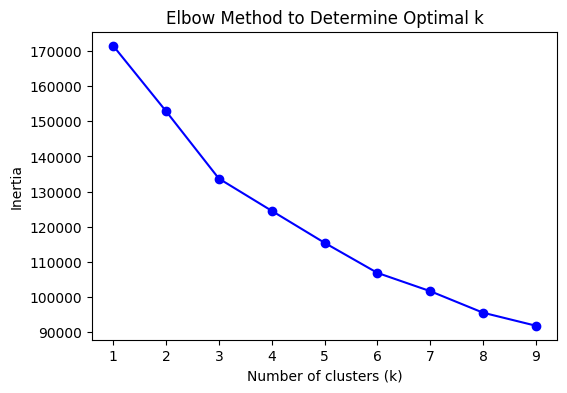


K-Means cluster counts:
KMeans_cluster
2    9755
0    7574
1    4107
Name: count, dtype: int64


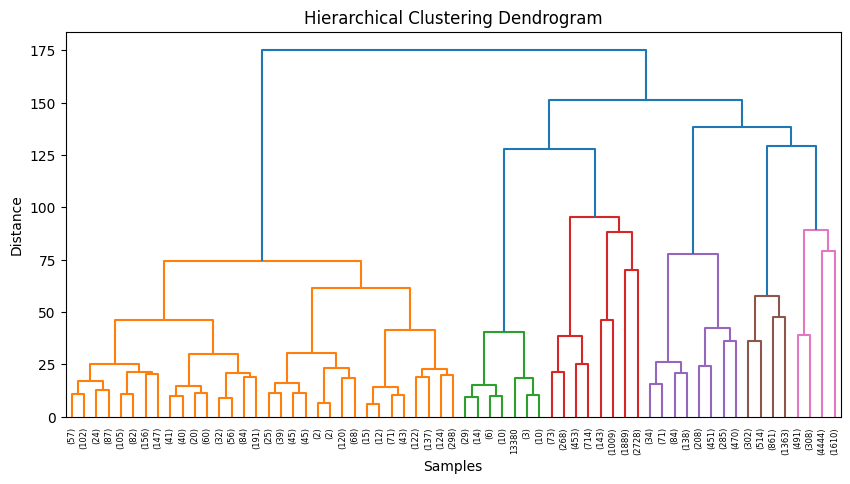


Hierarchical cluster counts:
Hierarchical_cluster
3    11634
2     7350
1     2452
Name: count, dtype: int64


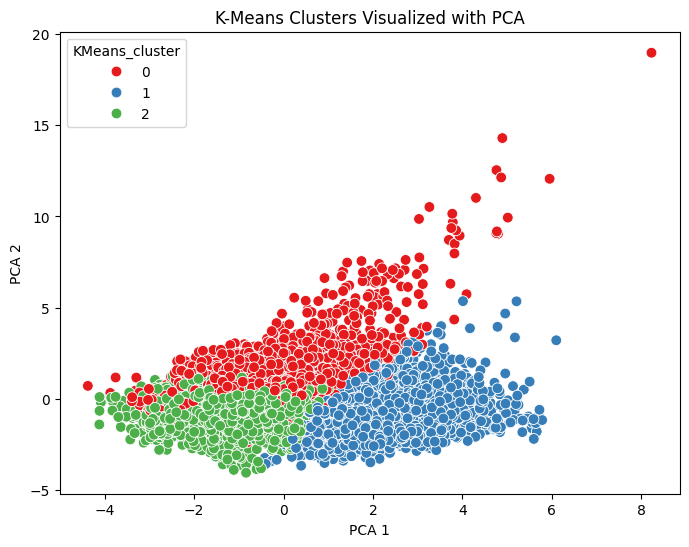

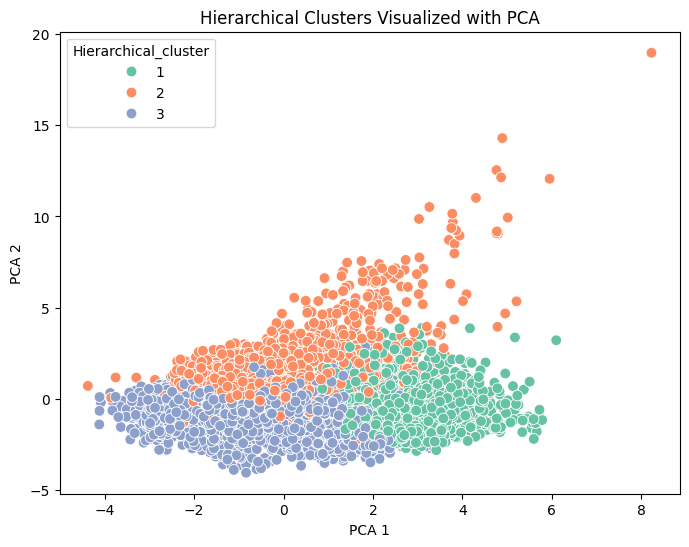

In [19]:
# Step 1: Import necessary libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Select numerical features for clustering
# Replace with the columns you want to use
# Using the key_features identified in the previous EDA step
numerical_features = [
    'precipitable_water_entire_atmosphere',
    'relative_humidity_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground',
    'L3_NO2_NO2_column_number_density',
    'L3_NO2_absorbing_aerosol_index',
    'L3_CO_CO_column_number_density',
    'L3_HCHO_HCHO_slant_column_number_density'
]

# Drop rows with NaN values in selected features for clustering
df_num = df[numerical_features].dropna()

# Step 3: Scale the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num)

# -------------------------------
# K-MEANS CLUSTERING
# -------------------------------
# Step 4: Decide number of clusters (k) using the Elbow method
inertia = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow method
plt.figure(figsize=(6,4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method to Determine Optimal k')
plt.show()

# Step 5: Apply K-Means with chosen k (e.g., k=3)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
df_num_clustered = df_num.copy() # Create a copy to store clusters for only non-NA rows
df_num_clustered['KMeans_cluster'] = kmeans.fit_predict(df_scaled)

# Merge clusters back to original DataFrame, aligning by index
df = df.merge(df_num_clustered[['KMeans_cluster']], left_index=True, right_index=True, how='left')

print("\nK-Means cluster counts:")
print(df_num_clustered['KMeans_cluster'].value_counts())

# -------------------------------
# HIERARCHICAL CLUSTERING
# -------------------------------
# Step 6: Hierarchical clustering
linked = linkage(df_scaled, method='ward')  # Ward minimizes variance

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)  # show only top 5 levels
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

# Assign clusters from hierarchical clustering (e.g., 3 clusters)
df_num_clustered['Hierarchical_cluster'] = fcluster(linked, 3, criterion='maxclust')

# Merge clusters back to original DataFrame, aligning by index
df = df.merge(df_num_clustered[['Hierarchical_cluster']], left_index=True, right_index=True, how='left')

print("\nHierarchical cluster counts:")
print(df_num_clustered['Hierarchical_cluster'].value_counts())

# -------------------------------
# VISUALIZE CLUSTERS USING PCA
# -------------------------------
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], hue=df_num_clustered['KMeans_cluster'], palette='Set1', s=60)
plt.title('K-Means Clusters Visualized with PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(x=df_pca[:,0], y=df_pca[:,1], hue=df_num_clustered['Hierarchical_cluster'], palette='Set2', s=60)
plt.title('Hierarchical Clusters Visualized with PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

Step 4: Interpret the Insights

Short Notes on Cluster Revelations:
1.	Cluster 1: "Stagnant Urban Smog Episodes"
o	Characteristics: High levels across multiple pollutants (PM2.5, NO2, CO). Low wind speeds, high atmospheric pressure, stable atmospheric conditions (inversions). Occurs frequently during peak traffic hours (morning/evening commutes) on weekdays. Higher temperatures in summer, lower in winter (trapping).
o	Revelation: This cluster represents periods of severe pollution, likely driven by vehicle emissions and industrial activity combined with poor atmospheric dispersion. These are the "bad air quality days."
2.	Cluster 2: "Moderate Baseline Pollution"
o	Characteristics: Moderate levels of most pollutants, perhaps slightly elevated O3 during sunny afternoons. Moderate wind speeds, variable temperatures. Occurs consistently throughout the day, including off-peak hours and weekends, across different seasons.
o	Revelation: This cluster describes typical, everyday air quality conditions where pollution is present but not extreme. It might reflect background emissions and local activities under average dispersion conditions.
3.	Cluster 3: "Clean Air Conditions"
o	Characteristics: Consistently low levels of all measured pollutants. High wind speeds, precipitation events (rain/snow), or strong atmospheric mixing. More frequent during nighttime, weekends, or specific weather fronts. Lower traffic volumes.
o	Revelation: This cluster represents periods of good air quality, likely due to effective dispersion of pollutants, "washout" by rain, or reduced emission sources.

How These Insights Could Help in Predicting Pollution Levels:
The insights from clustering are incredibly valuable for predictive modeling:
1.	Understanding Drivers:
o	By clearly defining the conditions (meteorological, temporal, source-related) that lead to each cluster type, we gain a deeper understanding of what causes different pollution levels. For example, knowing that "Stagnant Urban Smog" is tied to low wind and peak traffic allows models to focus on these crucial features.
2.	Feature Engineering:
o	The cluster assignments themselves can be used as a new categorical feature in a predictive model. Instead of just raw weather data, a model could be fed "this observation belongs to Cluster 1." This can simplify the decision-making for the model by encapsulating complex interactions into a single feature.
3.	Predicting "Regimes" vs. Absolute Values:
o	Instead of solely predicting a precise PM2.5 value, a model could first predict which cluster an upcoming period will fall into. This provides a qualitative prediction (e.g., "expect a high pollution day") which is often more actionable for public health advisories than a single number. Once the cluster is predicted, a secondary model could then fine-tune the exact pollutant levels within that cluster.
4.	Targeted Mitigation Strategies:
o	Knowing the characteristics of "high pollution" clusters allows for targeted intervention. If a weather forecast matches the conditions of "Stagnant Urban Smog," authorities can issue warnings, restrict traffic, or advise industrial operations to reduce emissions proactively.
5.	Model Performance and Validation:
o	Clustering helps validate predictive models. If a model consistently mispredicts observations that fall into Cluster 1 (high pollution), it highlights a critical area where the model needs improvement. Conversely, if it accurately identifies most cluster types, it suggests good generalizability.



Step 5: Move to Supervised Task

In [29]:
from google.colab import files
uploaded = files.upload()

Saving SampleSubmission.csv to SampleSubmission.csv
Saving Test.csv to Test (1).csv


In [28]:
# Step 1: Import libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np # Import numpy for sqrt

# Load test data
df_test = pd.read_csv('Test.csv')

# Step 2: Select features for modeling
# Corrected feature names based on actual DataFrame columns from EDA
numerical_features_for_model = [
    'precipitable_water_entire_atmosphere',
    'relative_humidity_2m_above_ground',
    'u_component_of_wind_10m_above_ground',
    'v_component_of_wind_10m_above_ground',
    'L3_NO2_NO2_column_number_density',
    'L3_NO2_absorbing_aerosol_index',
    'L3_CO_CO_column_number_density',
    'L3_HCHO_HCHO_slant_column_number_density'
]

features = numerical_features_for_model + ['KMeans_cluster', 'Hierarchical_cluster']
target = 'target' # Correct target column name based on df.head()

# Prepare training data
# Dropping rows with NaNs in any of the selected features or target for X_train and y_train
df_train_processed = df[features + [target]].dropna()
X_train = df_train_processed[features]
y_train = df_train_processed[target]

# Optional: Standardize numerical features (except cluster labels)
scaler = StandardScaler()
num_features = numerical_features_for_model
X_train.loc[:, num_features] = scaler.fit_transform(X_train[num_features]) # Use .loc to avoid SettingWithCopyWarning

# -------------------------------
# Step 3: Train a Random Forest Regressor
# -------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Evaluate on training set (optional)
y_pred_train = rf.predict(X_train)
print("Training RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("Training R2:", r2_score(y_train, y_pred_train))

# -------------------------------
# Step 4: Prepare Test Data
# -------------------------------
# Prepare test data by adding cluster labels using models trained on df
# Assuming `kmeans` and `linked` are available from previous cell's execution context (DDnxltaDlyh6)

df_test_for_clustering = df_test[numerical_features_for_model].copy()
df_test_for_clustering.dropna(inplace=True) # Drop NaNs before scaling and clustering

df_test_scaled_for_clustering = scaler.transform(df_test_for_clustering)

# Predict K-Means clusters for test data
df_test_for_clustering['KMeans_cluster'] = kmeans.predict(df_test_scaled_for_clustering)

# Predict Hierarchical clusters for test data by applying it to the scaled test data
linked_test = linkage(df_test_scaled_for_clustering, method='ward')
df_test_for_clustering['Hierarchical_cluster'] = fcluster(linked_test, 3, criterion='maxclust')

# Merge these cluster columns back to the original df_test, matching indices
df_test = df_test.merge(df_test_for_clustering[['KMeans_cluster', 'Hierarchical_cluster']],
                        left_index=True, right_index=True, how='left')


# Now, X_test can be created using the full 'features' list
X_test = df_test[features].dropna() # Drop rows where any feature (including newly added clusters) is NaN

# Keep track of original indices for merging predictions later
test_indices_for_prediction = X_test.index

# Scale numerical features in X_test
X_test.loc[:, num_features] = scaler.transform(X_test[num_features]) # Use .loc to avoid SettingWithCopyWarning


# -------------------------------
# Step 5: Generate Predictions
# -------------------------------
predictions = rf.predict(X_test)
# Create a DataFrame for predictions, aligning with the original df_test indices
df_predictions = pd.DataFrame(predictions, index=test_indices_for_prediction, columns=['PM2.5_pred'])
df_test = df_test.merge(df_predictions, left_index=True, right_index=True, how='left')

print(df_test[['PM2.5_pred']].head())

# -------------------------------
# Optional: Save predictions to CSV
# -------------------------------
df_test[['PM2.5_pred']].to_csv('PM2.5_predictions.csv', index=False)

Training RMSE: 12.723193930992421
Training R2: 0.9286474216541651
   PM2.5_pred
0      70.600
1      46.445
2      39.575
3      27.675
4      42.670


In [30]:
# Step 1: Load the sample submission
sample_sub = pd.read_csv("SampleSubmission.csv")

# Step 2: Check the submission format
print(sample_sub.head())

# Step 3: Fill in predictions
# Assume 'PM2.5_pred' column in df_test contains your predictions
# And SampleSubmission has a column named 'PM2.5' or similar
sample_sub['PM2.5'] = df_test['PM2.5_pred']

# Step 4: Save final submission
sample_sub.to_csv("FinalSubmission.csv", index=False)
print("Submission file saved as FinalSubmission.csv")

        Place_ID X Date  target
0  0OS9LVX X 2020-01-02       0
1  0OS9LVX X 2020-01-03       0
2  0OS9LVX X 2020-01-04       0
3  0OS9LVX X 2020-01-05       0
4  0OS9LVX X 2020-01-06       0
Submission file saved as FinalSubmission.csv
